### Objetivo:
Entender patrones de demanda, estacionalidad,
efecto promociones y comportamiento temporal
para diseñar features y modelos de forecasting.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_parquet("../data/processed/retail_dataset.parquet")

Realizamos la conversión de fecha, así pandas tratará estos valores como fecha

In [5]:
df["date"] = pd.to_datetime(df["date"])
df.dtypes

id                      object
item_id                 object
dept_id               category
cat_id                category
store_id              category
state_id              category
d                       object
sales                    int16
date            datetime64[ns]
wm_yr_wk                 int16
weekday               category
wday                      int8
month                     int8
year                     int16
event_name_1          category
event_type_1          category
event_name_2          category
event_type_2          category
snap_CA                   int8
snap_TX                   int8
snap_WI                   int8
sell_price             float32
dtype: object

### **Análisis de ventas globales** 

#### ¿Como evoluciona la demanda total?

In [6]:
daily_sales = (
    df.groupby("date")["sales"]
    .sum()
    .reset_index()
)

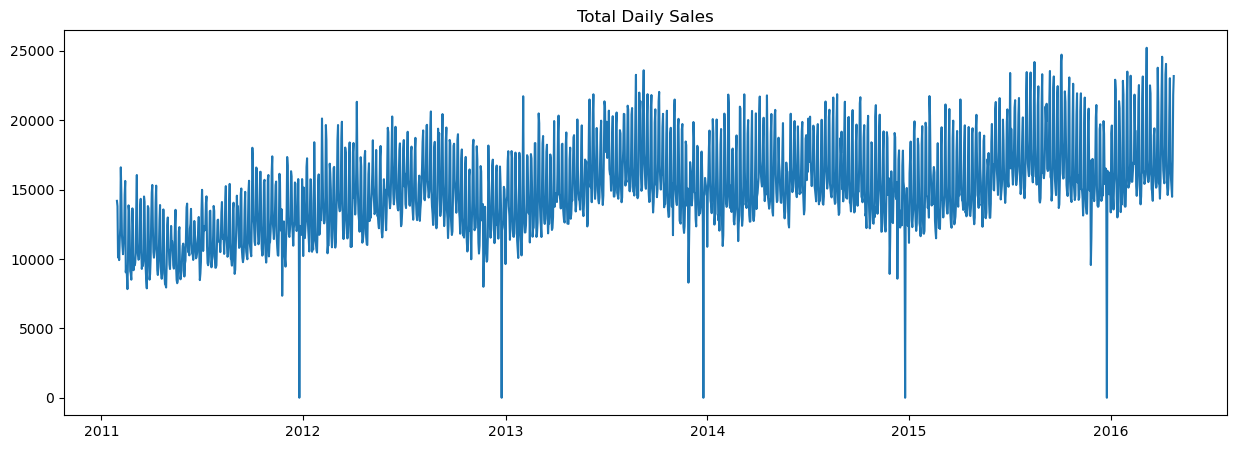

In [7]:
plt.figure(figsize=(15,5))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Total Daily Sales")
plt.show()

En esta gráfica se puede ver como los datos, sobretodo los años a partir del 2011 siguen una perioicidad que va anualmente en aumento, ya que aumentan de enero a mitad de año y después decaen levemente. Aunque se puede observar como todos los años, al final del año hay una caida importante de ventas; para ver la razón de este suceso vamos a ver estos valores con sus fechas.

In [10]:
resultado = daily_sales.nsmallest(15, "sales")
print(resultado)

           date  sales
1061 2013-12-25      5
696  2012-12-25      6
1426 2014-12-25      6
1791 2015-12-25      6
330  2011-12-25      8
299  2011-11-24   7356
19   2011-02-17   7835
54   2011-03-24   7889
89   2011-04-28   7951
663  2012-11-22   8002
88   2011-04-27   8135
87   2011-04-26   8176
109  2011-05-18   8258
1034 2013-11-28   8302
110  2011-05-19   8410


Tras esta comprobación, se puede ver como las ventas descienden todos los 25 de Diciembre, lo cual se le puede atribuir a el dia de Navidad. También se puede ver tanto en la gráfica como en la tabla de ventas mas bajas junto con sus fechas que la última semana de noviembre hay un día el cual las ventas bajan de manera representativa. Esto se debe a acción de gracias, el cual provoca que caigan las ventas también.

El claro indicio de  estacionalidad y patrones temporales claros justifican el uso de rolling statistics.

#### **Análisis semanal**

In [24]:
df["weekday"] = df["date"].dt.day_name()

In [26]:
weekday_sales = (
    df.groupby("weekday")["sales"]
    .mean()
)

order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = weekday_sales.reindex(order)

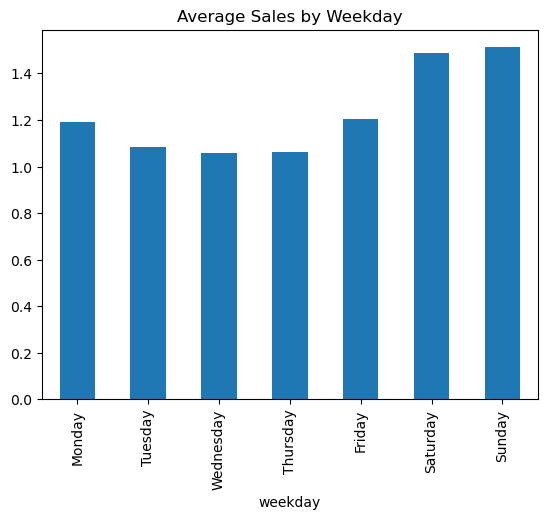

In [27]:
weekday_sales.plot(kind="bar")
plt.title("Average Sales by Weekday")
plt.show()

Los días de la semana que más ventas se realizan son sábado y domingo.

#### **Ventas 0**

In [11]:
zero_sales_ratio = (df["sales"] == 0).mean()

print(f"Zero sales ratio: {zero_sales_ratio:.2%}")

Zero sales ratio: 66.21%


#### Categorías más vendidas

In [12]:
category_sales = (
    df.groupby("cat_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

C:\Users\tela\AppData\Local\Temp\ipykernel_31304\1740722808.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("cat_id")["sales"]


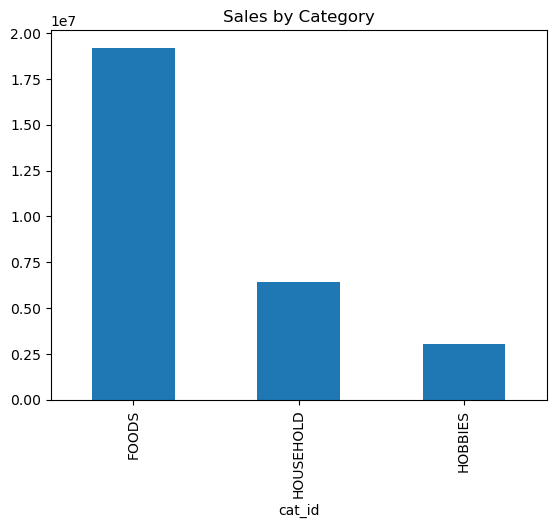

In [13]:
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.show()

In [14]:
store_sales = (
    df.groupby("store_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

C:\Users\tela\AppData\Local\Temp\ipykernel_31304\2619874928.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("store_id")["sales"]


#### **Análisis por tienda**

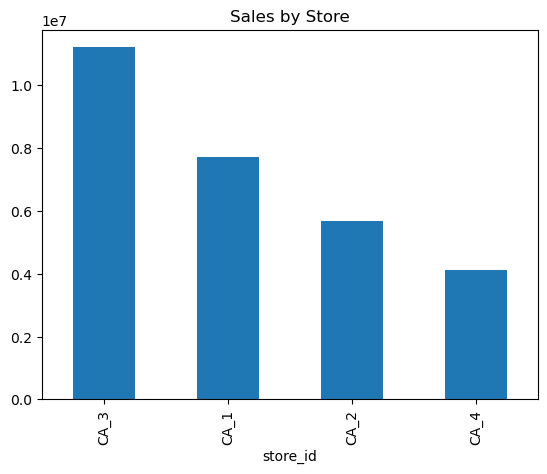

In [15]:
store_sales.plot(kind="bar")
plt.title("Sales by Store")
plt.show()

Aunque se puede observar que la tienda CA_3 es la que más vende en california, esto no se traduce en que tenga más ventas relativas, sino más ventas absolutas, esto se puede deber a cacterísticas como la localización o el tamaño de tienda las cuales no tenemos en el dataset.

#### **Relevancia del precio**

In [16]:
df[["sales", "sell_price"]].corr()

,sales,sell_price
sales,1.000000,-0.148482
sell_price,-0.148482,1.000000


En la matriz de correlación anterior se puede observar como el precio tiene una correlación negativa alta respecto de las ventas. Aunque esto puede estar sesgado por la diferencia entre categoría y productos, por lo que una correlación específica por categoría sería mas productiva.

#### ¿Aumentan las ventas los eventos?

In [18]:
df.groupby("event_name_1")["sales"].mean().sort_values(ascending=False)

C:\Users\tela\AppData\Local\Temp\ipykernel_31304\2285806734.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("event_name_1")["sales"].mean().sort_values(ascending=False)


event_name_1
LaborDay               1.551902
Easter                 1.452296
SuperBowl              1.430647
OrthodoxEaster         1.372274
Father's day           1.338062
Eid al-Fitr            1.309347
Purim End              1.298677
ColumbusDay            1.279551
PresidentsDay          1.275568
Ramadan starts         1.270663
MartinLutherKingDay    1.260298
MemorialDay            1.258298
VeteransDay            1.247835
Mother's day           1.244588
IndependenceDay        1.235585
EidAlAdha              1.224680
NBAFinalsEnd           1.203067
StPatricksDay          1.194381
OrthodoxChristmas      1.186569
Pesach End             1.185766
Cinco De Mayo          1.153411
Chanukah End           1.144752
NBAFinalsStart         1.107461
ValentinesDay          1.083853
Halloween              1.070794
LentStart              1.034082
LentWeek2              1.012846
NewYear                0.906445
Thanksgiving           0.691374
Christmas              0.000508
Name: sales, dtype: float64

Se puede ver como festividades como Navidad ,Acción de gracias o Año Nuevo afectan negativamente a las ventas, mientras que el resto de eventos o festividades tienen un impacto más positivo.

#### **Conclusiones**

1. Existe una clara componente temporal y estacional en la demanda.

2. Se observan patrones semanales consistentes que justifican features basadas en calendario.

3. Determinados eventos y festividades alteran significativamente el comportamiento de ventas.

4. Las diferencias entre categorías y tiendas sugieren comportamientos heterogéneos de demanda.

5. El análisis justifica el uso de:
   - lag features,
   - rolling statistics,
   - variables calendario,
   - variables de precio y eventos.